In [1]:
# 필요한 라이브러리를 import한 후 데이터를 불러오는 코드를 입력하세요
import platform
import matplotlib.pyplot as plt
import seaborn as sns

# OS에 따른 폰트 설정
os_name = platform.system()

if os_name == 'Windows': # 윈도우
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif os_name == 'Darwin': # 맥, macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else: # Linux (Colab 등)
    # Colab 환경에서만 apt-get이 작동하므로 예외 처리
    try:
        plt.rcParams['font.family'] = 'NanumGothic'
    except:
        pass

plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid", font=plt.rcParams['font.family'], rc={"axes.unicode_minus": False})

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
file_path = '서울교통공사_역별_일별_시간대별_승하차인원_2020_2025_통합.csv'

df = pd.read_csv(
    file_path,
    encoding='utf-8-sig',
    dtype={'역번호': 'string'},
    low_memory=False
)

df.shape

(1203704, 29)

In [4]:
df.head()

,통합연번,수송일자,연도,호선,역번호,역명,승하차구분,06시이전,06-07시간대,07-08시간대,...,17-18시간대,18-19시간대,19-20시간대,20-21시간대,21-22시간대,22-23시간대,23시이후,23-24시간대,24시이후,합계
0,1,2020-01-01,2020,1호선,150,서울역,승차,356,280,313,...,3342,3002,2857,2311,2523,1830,1012.0,NaN,NaN,36641
1,2,2020-01-01,2020,1호선,150,서울역,하차,235,952,828,...,2261,1922,1696,1620,1181,768,503.0,NaN,NaN,30085
2,3,2020-01-01,2020,1호선,151,시청,승차,105,118,123,...,1234,1383,1271,1061,991,572,219.0,NaN,NaN,12212
3,4,2020-01-01,2020,1호선,151,시청,하차,81,223,334,...,849,602,435,293,273,174,175.0,NaN,NaN,10608
4,5,2020-01-01,2020,1호선,152,종각,승차,798,366,198,...,1890,1879,1827,1955,1800,1259,412.0,NaN,NaN,20523


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1203704 entries, 0 to 1203703
Data columns (total 29 columns):
 #   Column    Non-Null Count    Dtype  
---  ------    --------------    -----  
 0   통합연번      1203704 non-null  int64  
 1   수송일자      1203704 non-null  str    
 2   연도        1203704 non-null  int64  
 3   호선        1203704 non-null  str    
 4   역번호       1203703 non-null  string 
 5   역명        1203704 non-null  str    
 6   승하차구분     1203704 non-null  str    
 7   06시이전     1203704 non-null  int64  
 8   06-07시간대  1203704 non-null  int64  
 9   07-08시간대  1203704 non-null  int64  
 10  08-09시간대  1203704 non-null  int64  
 11  09-10시간대  1203704 non-null  int64  
 12  10-11시간대  1203704 non-null  int64  
 13  11-12시간대  1203704 non-null  int64  
 14  12-13시간대  1203704 non-null  int64  
 15  13-14시간대  1203704 non-null  int64  
 16  14-15시간대  1203704 non-null  int64  
 17  15-16시간대  1203704 non-null  int64  
 18  16-17시간대  1203704 non-null  int64  
 19  17-18시간대  1203704 non-null  int6

In [6]:
df.columns.tolist()
# 2020~2021: 23시 이후 하나로 묶여 있음
# 2022~2025: 23~24시, 24시 이후로 분리됨
# 일단은 20-25년 합치면서 칼럼을 따로 들고왔는데, 추후 연도 어떻게 할 것인지 논의 필요 (처음에는 22~23시까지를 공통 시간대로 분석하고, 23시 이후는 별도로 확인하는 게 안전할 거 같음)

['통합연번',
 '수송일자',
 '연도',
 '호선',
 '역번호',
 '역명',
 '승하차구분',
 '06시이전',
 '06-07시간대',
 '07-08시간대',
 '08-09시간대',
 '09-10시간대',
 '10-11시간대',
 '11-12시간대',
 '12-13시간대',
 '13-14시간대',
 '14-15시간대',
 '15-16시간대',
 '16-17시간대',
 '17-18시간대',
 '18-19시간대',
 '19-20시간대',
 '20-21시간대',
 '21-22시간대',
 '22-23시간대',
 '23시이후',
 '23-24시간대',
 '24시이후',
 '합계']

In [7]:
df.shape

(1203704, 29)

In [8]:
df['연도'].value_counts().sort_index()

연도
2020    202280
2021    204374
2022    199080
2023    199270
2024    199410
2025    199290
Name: count, dtype: int64

In [9]:
time_cols = [
    '06시이전',
    '06-07시간대',
    '07-08시간대',
    '08-09시간대',
    '09-10시간대',
    '10-11시간대',
    '11-12시간대',
    '12-13시간대',
    '13-14시간대',
    '14-15시간대',
    '15-16시간대',
    '16-17시간대',
    '17-18시간대',
    '18-19시간대',
    '19-20시간대',
    '20-21시간대',
    '21-22시간대',
    '22-23시간대',
    '23시이후',
    '23-24시간대',
    '24시이후'
]

In [10]:
common_time_cols = [
    '06시이전',
    '06-07시간대',
    '07-08시간대',
    '08-09시간대',
    '09-10시간대',
    '10-11시간대',
    '11-12시간대',
    '12-13시간대',
    '13-14시간대',
    '14-15시간대',
    '15-16시간대',
    '16-17시간대',
    '17-18시간대',
    '18-19시간대',
    '19-20시간대',
    '20-21시간대',
    '21-22시간대',
    '22-23시간대'
]

In [11]:
# 심야시간대는 연도별 기준이 달라서 일단 별도로 뒀음
late_time_cols = [
    '23시이후',
    '23-24시간대',
    '24시이후'
]

In [12]:
df['수송일자'] = pd.to_datetime(df['수송일자'], errors='coerce')

df['연도'] = pd.to_numeric(df['연도'], errors='coerce')

for col in time_cols + ['합계']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

for col in ['호선', '역번호', '역명', '승하차구분']:
    df[col] = df[col].astype('string').str.strip()

In [13]:
df['역번호'] = df['역번호'].str.replace(r'\.0$', '', regex=True)

In [14]:
df[df['역번호'].isna()]

,통합연번,수송일자,연도,호선,역번호,역명,승하차구분,06시이전,06-07시간대,07-08시간대,...,17-18시간대,18-19시간대,19-20시간대,20-21시간대,21-22시간대,22-23시간대,23시이후,23-24시간대,24시이후,합계
539134,539135,2022-08-31,2022,7호선,<NA>,광명사거리,승차,801,1299,3405,...,1376,1283,779,521,448,346,NaN,124.0,15.0,23307


In [15]:
# 광명사거리역 결측치 수정
condition = (
    (df['호선'] == '7호선') &
    (df['역명'] == '광명사거리') &
    (df['역번호'].isna())
)

df.loc[condition, '역번호'] = '2750'

In [16]:
# 역 고유 ID 생성
df['역ID'] = df['호선'] + '_' + df['역번호']

In [17]:
df[['호선', '역번호', '역명', '역ID']].head()

,호선,역번호,역명,역ID
0,1호선,150,서울역,1호선_150
1,1호선,150,서울역,1호선_150
2,1호선,151,시청,1호선_151
3,1호선,151,시청,1호선_151
4,1호선,152,종각,1호선_152


In [18]:
# 같은 역이어도 역 이름 변경된 사례 있음
# 분석 기준은 역 ID / 차트 표시에는 역명_표준 사용
latest_station_name = (
    df.sort_values('수송일자')
    .drop_duplicates('역ID', keep='last')
    .set_index('역ID')['역명']
)

df['역명_표준'] = df['역ID'].map(latest_station_name)

In [19]:
#결측치 확인
missing_summary = pd.DataFrame({
    '자료형': df.dtypes.astype(str),
    '결측치수': df.isna().sum(),
    '결측치비율': df.isna().mean() * 100
})

missing_summary[missing_summary['결측치수'] > 0]

,자료형,결측치수,결측치비율
23시이후,float64,797050,66.216445
23-24시간대,float64,406654,33.783555
24시이후,float64,489000,40.624605


연도별로 심야시간대 칼럼이 다른데, 데이터를 합치다보니 결측치 발생 -> 무조건 지우거나 대체값 넣으면 안 됨 !! 합의 필요..

In [20]:
# 중복 확인
duplicate_count = df.duplicated(
    subset=['수송일자', '역ID', '승하차구분']
).sum()

duplicate_count

np.int64(0)

In [21]:
# 음수 데이터 확인
negative_count = (df[time_cols] < 0).sum()

negative_count[negative_count > 0]

17-18시간대    5
dtype: int64

In [22]:
negative_condition = (df[time_cols] < 0).any(axis=1)

negative_rows = df.loc[
    negative_condition,
    ['수송일자', '호선', '역번호', '역명', '승하차구분'] + time_cols + ['합계']
]

negative_rows

,수송일자,호선,역번호,역명,승하차구분,06시이전,06-07시간대,07-08시간대,08-09시간대,09-10시간대,...,17-18시간대,18-19시간대,19-20시간대,20-21시간대,21-22시간대,22-23시간대,23시이후,23-24시간대,24시이후,합계
147737,2020-09-24,6호선,2636,신당,하차,39,206,691,1703,883,...,-101,460,677,354,224,248,417.0,NaN,NaN,7773
148270,2020-09-25,6호선,2626,대흥(서강대앞),승차,81,196,563,745,438,...,-53,1053,452,312,292,325,124.0,NaN,NaN,7041
148291,2020-09-25,6호선,2636,신당,하차,34,207,633,1651,900,...,-35,553,717,333,232,252,339.0,NaN,NaN,7908
149403,2020-09-27,6호선,2636,신당,하차,10,60,112,300,204,...,-114,286,422,222,199,198,357.0,NaN,NaN,3682
149957,2020-09-28,6호선,2636,신당,하차,36,205,677,1647,868,...,-100,385,622,313,233,250,379.0,NaN,NaN,7598


In [23]:
# 음수 이상값 제거
df['음수이상치여부'] = negative_condition

clean_df = df[df['음수이상치여부'] == False].copy()

clean_df.shape

(1203699, 32)

In [24]:
# 합계 검증
calculated_total = df[time_cols].sum(axis=1, min_count=1)

total_mismatch = (df['합계'] != calculated_total).sum()

total_mismatch

np.int64(0)

In [25]:
# 날짜 파생변수 생성
clean_df['월'] = clean_df['수송일자'].dt.month
clean_df['일'] = clean_df['수송일자'].dt.day
clean_df['요일번호'] = clean_df['수송일자'].dt.dayofweek

In [26]:
weekday_map = {
    0: '월요일',
    1: '화요일',
    2: '수요일',
    3: '목요일',
    4: '금요일',
    5: '토요일',
    6: '일요일'
}

clean_df['요일'] = clean_df['요일번호'].map(weekday_map)

In [27]:
%pip install holidays


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [28]:
# 공휴일 구분
import holidays

kr_holidays = holidays.KR(years=range(2020, 2026))
holiday_dates = set(kr_holidays.keys())

clean_df['공휴일여부'] = clean_df['수송일자'].dt.date.isin(holiday_dates)

In [29]:
conditions = [
    clean_df['공휴일여부'] | (clean_df['요일번호'] == 6),
    clean_df['요일번호'] == 5
]

choices = [
    '일요일',
    '토요일'
]

clean_df['요일구분'] = np.select(
    conditions,
    choices,
    default='평일'
)

In [30]:
clean_df[['수송일자', '요일', '공휴일여부', '요일구분']].drop_duplicates().head(10)

,수송일자,요일,공휴일여부,요일구분
0,2020-01-01,수요일,True,일요일
550,2020-01-02,목요일,False,평일
1100,2020-01-03,금요일,False,평일
1650,2020-01-04,토요일,False,토요일
2202,2020-01-05,일요일,False,일요일
2752,2020-01-06,월요일,False,평일
3304,2020-01-07,화요일,False,평일
3856,2020-01-08,수요일,False,평일
4408,2020-01-09,목요일,False,평일
4960,2020-01-10,금요일,False,평일


**연도별 데이터 범위 확인**

In [31]:
# 단순 연간 합계만 보면 윤년 여부와 역 포함 범위가 영향을 주어서 총승하차보다 일평균승하차를 보는 것이 나음.

year_summary = (
    clean_df.groupby('연도')
    .agg(
        행수=('통합연번', 'size'),
        시작일=('수송일자', 'min'),
        종료일=('수송일자', 'max'),
        날짜수=('수송일자', 'nunique'),
        역수=('역ID', 'nunique'),
        총승하차=('합계', 'sum')
    )
    .reset_index()
)

year_summary['일평균승하차'] = (
    year_summary['총승하차'] / year_summary['날짜수']
)

year_summary

,연도,행수,시작일,종료일,날짜수,역수,총승하차,일평균승하차
0,2020,202275,2020-01-01,2020-12-31,366,280,2564408395,7.006580e+06
1,2021,204374,2021-01-01,2021-12-31,365,284,2581848190,7.073557e+06
2,2022,199080,2022-01-01,2022-12-31,365,279,2835350063,7.768082e+06
3,2023,199270,2023-01-01,2023-12-31,365,282,3096242690,8.482857e+06
4,2024,199410,2024-01-01,2024-12-31,366,273,3193746993,8.726085e+06
5,2025,199290,2025-01-01,2025-12-31,365,273,3241663605,8.881270e+06


In [32]:
#  연도별 포함 역 수가 다르기 때문에 2020~2025년을 그대로 비교하면 역 추가, 제외 효과가 섞임 -> 모든 연도에 공통으로 있는 역 추출 필요

station_year_count = (
    clean_df[['역ID', '연도']]
    .drop_duplicates()
    .groupby('역ID')['연도']
    .nunique()
)

common_station_ids = station_year_count[
    station_year_count == clean_df['연도'].nunique()
].index

len(common_station_ids)

268

In [33]:
common_df = clean_df[
    clean_df['역ID'].isin(common_station_ids)
].copy()

**연도별 일평균 승하차 추이**

In [34]:
daily_common = (
    common_df.groupby(['수송일자', '연도'])['합계']
    .sum()
    .reset_index()
)

annual_daily_average = (
    daily_common.groupby('연도')['합계']
    .mean()
    .reset_index(name='일평균승하차')
)

annual_daily_average

,연도,일평균승하차
0,2020,6.870275e+06
1,2021,6.913655e+06
2,2022,7.726561e+06
3,2023,8.432421e+06
4,2024,8.667742e+06
5,2025,8.814294e+06


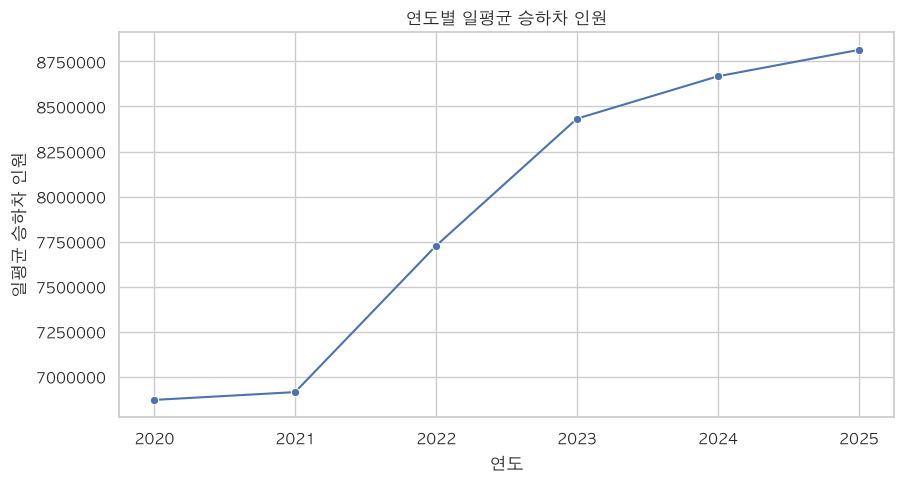

In [35]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=annual_daily_average,
    x='연도',
    y='일평균승하차',
    marker='o'
)

plt.title('연도별 일평균 승하차 인원')
plt.xlabel('연도')
plt.ylabel('일평균 승하차 인원')
plt.ticklabel_format(style='plain', axis='y')
plt.show()

**평일, 토요일, 일요일 비교**

In [36]:
daily_total = (
    clean_df.groupby(
        ['수송일자', '연도', '요일구분']
    )['합계']
    .sum()
    .reset_index()
)

daytype_average = (
    daily_total.groupby(
        ['연도', '요일구분']
    )['합계']
    .mean()
    .reset_index(name='일평균승하차')
)

daytype_average.head()

,연도,요일구분,일평균승하차
0,2020,일요일,3.675381e+06
1,2020,토요일,5.268054e+06
2,2020,평일,8.246464e+06
3,2021,일요일,3.785726e+06
4,2021,토요일,5.395776e+06


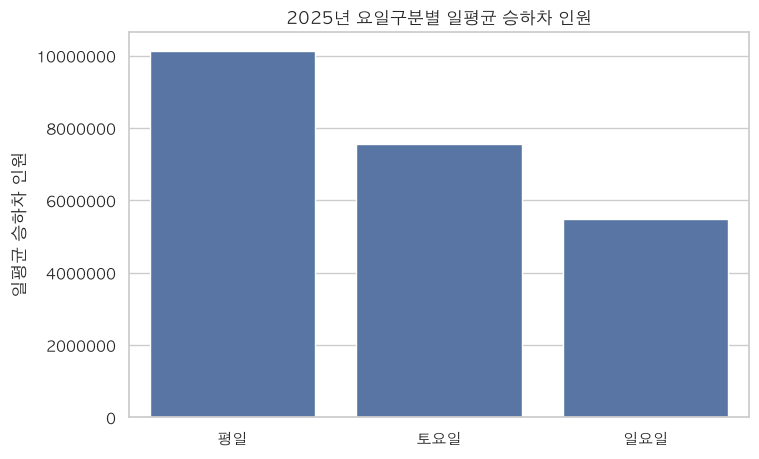

In [37]:
daytype_2025 = daytype_average[
    daytype_average['연도'] == 2025
]

plt.figure(figsize=(8, 5))

sns.barplot(
    data=daytype_2025,
    x='요일구분',
    y='일평균승하차',
    order=['평일', '토요일', '일요일']
)

plt.title('2025년 요일구분별 일평균 승하차 인원')
plt.xlabel('')
plt.ylabel('일평균 승하차 인원')
plt.ticklabel_format(style='plain', axis='y')
plt.show()

**시간대별 패턴 분석**

In [38]:
daily_hourly = (
    clean_df.groupby(
        ['수송일자', '연도', '요일구분', '승하차구분']
    )[common_time_cols]
    .sum()
    .reset_index()
)

In [39]:
# 요일 구분별 평균

average_hourly = (
    daily_hourly.groupby(
        ['연도', '요일구분', '승하차구분']
    )[common_time_cols]
    .mean()
    .reset_index()
)

In [40]:
hourly_long = average_hourly.melt(
    id_vars=['연도', '요일구분', '승하차구분'],
    value_vars=common_time_cols,
    var_name='시간대',
    value_name='평균인원'
)

hourly_long['시간대'] = pd.Categorical(
    hourly_long['시간대'],
    categories=common_time_cols,
    ordered=True
)

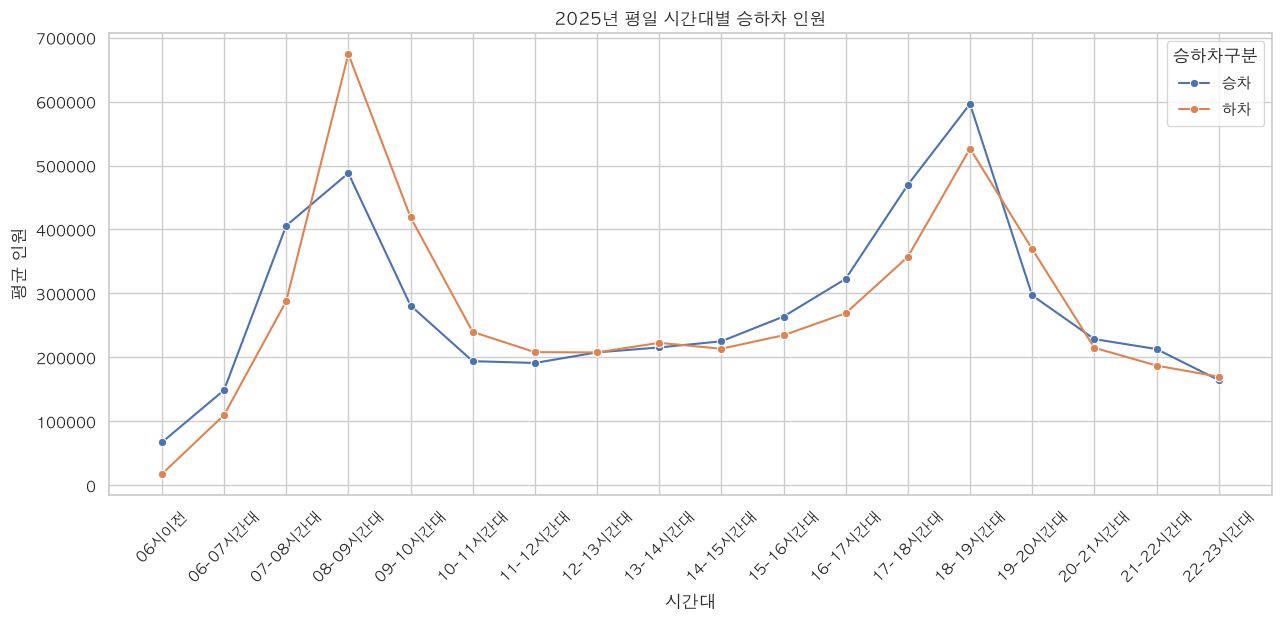

In [41]:
hourly_2025_weekday = hourly_long[
    (hourly_long['연도'] == 2025) &
    (hourly_long['요일구분'] == '평일')
]

plt.figure(figsize=(15, 6))

sns.lineplot(
    data=hourly_2025_weekday,
    x='시간대',
    y='평균인원',
    hue='승하차구분',
    marker='o'
)

plt.title('2025년 평일 시간대별 승하차 인원')
plt.xlabel('시간대')
plt.ylabel('평균 인원')
plt.xticks(rotation=45)
plt.ticklabel_format(style='plain', axis='y')
plt.show()

In [42]:
stadium_df = clean_df[
    (clean_df['연도'] >= 2020) &
    (clean_df['연도'] <= 2025) &
    (clean_df['호선'] == '2호선') &
    (clean_df['역명_표준'] == '종합운동장') &
    (clean_df['승하차구분'] == '승차')
].copy()

stadium_df.shape

(2192, 38)

In [43]:
stadium_df[
    ['호선', '역번호', '역ID', '역명_표준']
].drop_duplicates()

,호선,역번호,역ID,역명_표준
54,2호선,218,2호선_218,종합운동장


In [44]:
clean_df['역명_표준'] = clean_df['역명_표준'].astype('string').str.strip()

stadium_df = clean_df[
    (clean_df['연도'].between(2020, 2025)) &
    (clean_df['호선'] == '2호선') &
    (clean_df['역명_표준'] == '종합운동장') &
    (clean_df['승하차구분'] == '승차')
].copy()

In [45]:
stadium_df.groupby('연도').size()

연도
2020    366
2021    365
2022    365
2023    365
2024    366
2025    365
dtype: int64

In [46]:
stadium_df['23시이후_통합'] = (
    stadium_df[
        ['23시이후', '23-24시간대', '24시이후']
    ]
    .fillna(0)
    .sum(axis=1)
)

In [47]:
evening_cols = [
    '18-19시간대',
    '19-20시간대',
    '20-21시간대',
    '21-22시간대',
    '22-23시간대',
    '23시이후_통합'
]

In [48]:
for col in evening_cols:
    stadium_df[col] = pd.to_numeric(
        stadium_df[col],
        errors='coerce'
    )

In [49]:
# 날짜별 야간 승차 인원
stadium_day = stadium_df[
    [
        '수송일자',
        '연도',
        '요일구분'
    ] + evening_cols
].copy()

In [50]:
stadium_day['18시이후승차'] = (
    stadium_day[evening_cols].sum(axis=1)
)
stadium_day.head()

,수송일자,연도,요일구분,18-19시간대,19-20시간대,20-21시간대,21-22시간대,22-23시간대,23시이후_통합,18시이후승차
54,2020-01-01,2020,일요일,337,813,382,174,75,57.0,1838.0
604,2020-01-02,2020,평일,741,367,274,290,470,137.0,2279.0
1154,2020-01-03,2020,평일,1057,477,360,671,498,152.0,3215.0
1704,2020-01-04,2020,토요일,392,217,223,636,147,79.0,1694.0
2256,2020-01-05,2020,일요일,956,533,492,145,96,47.0,2269.0


In [51]:
# 연도별 야간 추이
stadium_year_average = (
    stadium_day.groupby('연도')['18시이후승차']
    .mean()
    .reset_index(name='일평균_18시이후승차')
)

stadium_year_average

,연도,일평균_18시이후승차
0,2020,1586.199454
1,2021,1726.882192
2,2022,4881.813699
3,2023,5232.331507
4,2024,5664.784153
5,2025,6294.517808


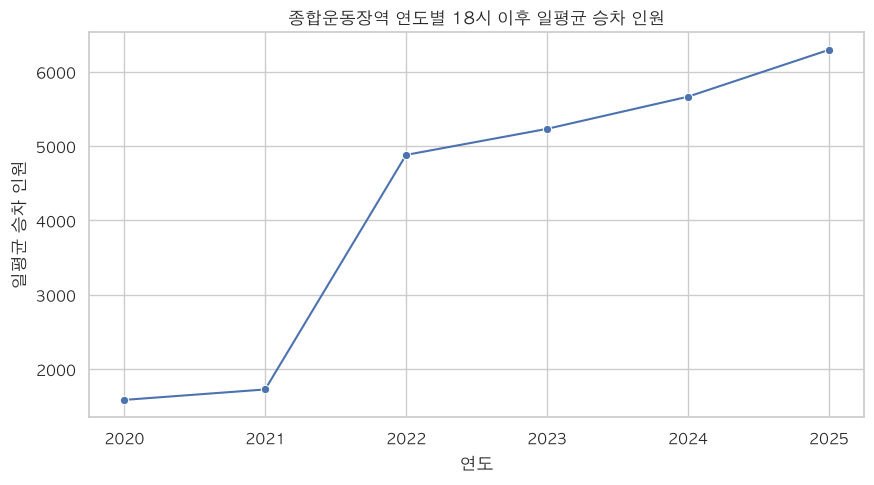

In [52]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=stadium_year_average,
    x='연도',
    y='일평균_18시이후승차',
    marker='o'
)

plt.title('종합운동장역 연도별 18시 이후 일평균 승차 인원')
plt.xlabel('연도')
plt.ylabel('일평균 승차 인원')
plt.ticklabel_format(style='plain', axis='y')
plt.show()

In [53]:
stadium_hour = stadium_day.melt(
    id_vars=[
        '수송일자',
        '연도',
        '요일구분'
    ],
    value_vars=evening_cols,
    var_name='시간대',
    value_name='승차인원'
)
stadium_hour['시간대'] = pd.Categorical(
    stadium_hour['시간대'],
    categories=evening_cols,
    ordered=True
)
stadium_hour.head()

,수송일자,연도,요일구분,시간대,승차인원
0,2020-01-01,2020,일요일,18-19시간대,337.0
1,2020-01-02,2020,평일,18-19시간대,741.0
2,2020-01-03,2020,평일,18-19시간대,1057.0
3,2020-01-04,2020,토요일,18-19시간대,392.0
4,2020-01-05,2020,일요일,18-19시간대,956.0


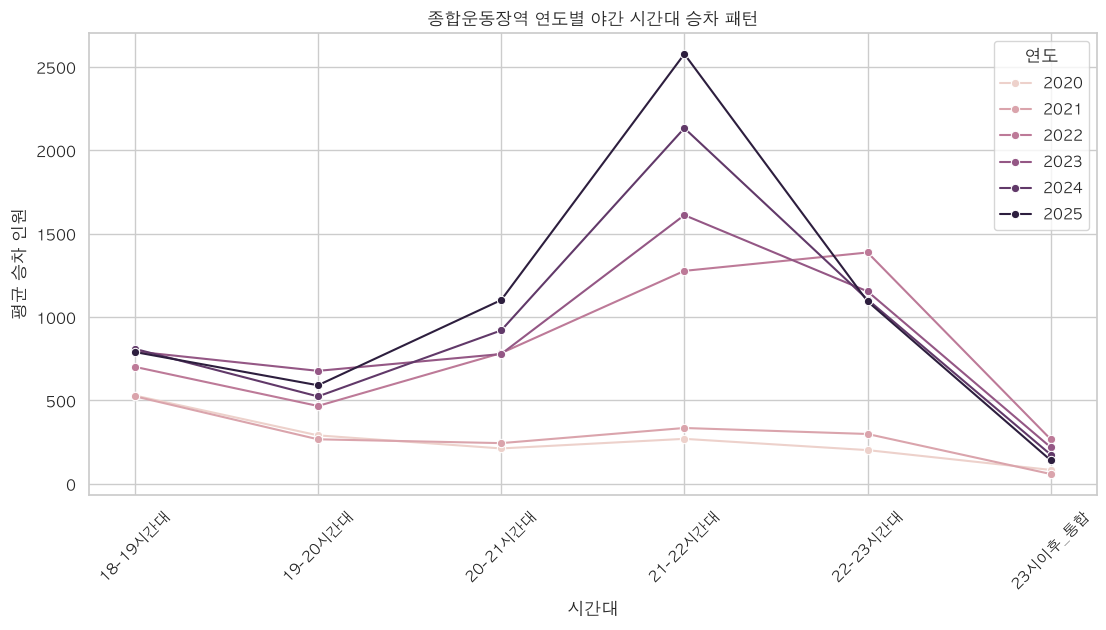

In [54]:
# 연도별 시간대 패턴 확인
stadium_year_hour = (
    stadium_hour.groupby(
        ['연도', '시간대'],
        observed=True
    )['승차인원']
    .mean()
    .reset_index(name='평균승차인원')
)
plt.figure(figsize=(13, 6))

sns.lineplot(
    data=stadium_year_hour,
    x='시간대',
    y='평균승차인원',
    hue='연도',
    marker='o'
)

plt.title('종합운동장역 연도별 야간 시간대 승차 패턴')
plt.xlabel('시간대')
plt.ylabel('평균 승차 인원')
plt.xticks(rotation=45)
plt.ticklabel_format(style='plain', axis='y')
plt.show()

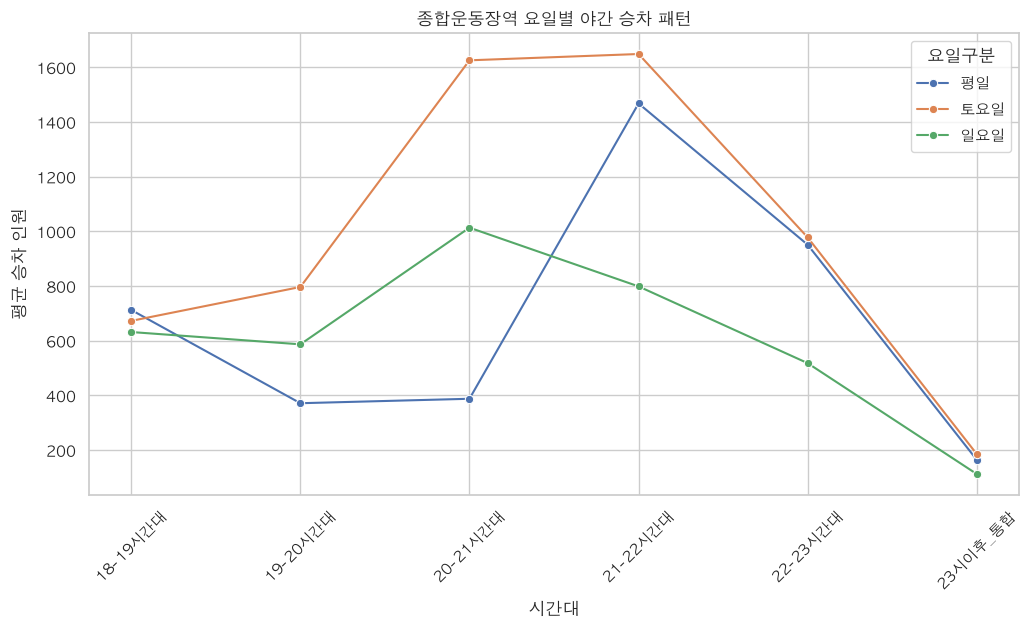

In [55]:
# 평일, 토요일, 일요일 비교
stadium_daytype_hour = (
    stadium_hour.groupby(
        ['요일구분', '시간대'],
        observed=True
    )['승차인원']
    .mean()
    .reset_index(name='평균승차인원')
)
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=stadium_daytype_hour,
    x='시간대',
    y='평균승차인원',
    hue='요일구분',
    hue_order=['평일', '토요일', '일요일'],
    marker='o'
)

plt.title('종합운동장역 요일별 야간 승차 패턴')
plt.xlabel('시간대')
plt.ylabel('평균 승차 인원')
plt.xticks(rotation=45)
plt.ticklabel_format(style='plain', axis='y')
plt.show()

In [56]:
# 날짜별 평시 기준 계산
stadium_baseline = (
    stadium_hour.groupby(
        ['연도', '요일구분', '시간대'],
        observed=True
    )['승차인원']
    .median()
    .reset_index(name='평시승차인원')
)
stadium_compare = stadium_hour.merge(
    stadium_baseline,
    on=[
        '연도',
        '요일구분',
        '시간대'
    ],
    how='left'
)

In [57]:
# 평소 대비 증가 인원과 증가율 계산
stadium_compare['증가인원'] = (
    stadium_compare['승차인원'] -
    stadium_compare['평시승차인원']
)
stadium_compare['증가율'] = np.where(
    stadium_compare['평시승차인원'] > 0,
    (
        stadium_compare['승차인원'] /
        stadium_compare['평시승차인원']
    ) - 1,
    np.nan
)
stadium_compare['증가율_pct'] = (
    stadium_compare['증가율'] * 100
)
stadium_compare['초과승차인원'] = (
    stadium_compare['증가인원'].clip(lower=0)
)

stadium_compare.columns

Index(['수송일자', '연도', '요일구분', '시간대', '승차인원', '평시승차인원', '증가인원', '증가율', '증가율_pct',
       '초과승차인원'],
      dtype='str')

In [58]:
# 날짜별 야간 초과 수요 계산
stadium_day_result = (
    stadium_compare.groupby(
        [
            '수송일자',
            '연도',
            '요일구분'
        ]
    )
    .agg(
        실제승차인원=('승차인원', 'sum'),
        평시승차인원=('평시승차인원', 'sum'),
        초과승차인원=('초과승차인원', 'sum')
    )
    .reset_index()
)

#날짜별 전체 증가율 계산
stadium_day_result['전체증가율'] = np.where(
    stadium_day_result['평시승차인원'] > 0,
    (
        stadium_day_result['실제승차인원'] /
        stadium_day_result['평시승차인원']
    ) - 1,
    np.nan
)

stadium_day_result['전체증가율_pct'] = (
    stadium_day_result['전체증가율'] * 100
)

In [59]:
# 날짜별 최대 증가 시간대 계산
stadium_peak_hour = (
    stadium_compare.loc[
        stadium_compare.groupby('수송일자')['증가인원'].idxmax(),
        [
            '수송일자',
            '시간대',
            '승차인원',
            '평시승차인원',
            '증가인원',
            '증가율_pct'
        ]
    ]
    .reset_index(drop=True)
)
stadium_peak_hour = stadium_peak_hour.rename(
    columns={
        '시간대': '최대증가시간대',
        '승차인원': '최대시간대승차인원',
        '평시승차인원': '최대시간대평시인원',
        '증가인원': '최대시간대증가인원',
        '증가율_pct': '최대시간대증가율_pct'
    }
)
stadium_eda_result = stadium_day_result.merge(
    stadium_peak_hour,
    on='수송일자',
    how='left'
)

In [60]:
# 평소보다 수요가 초과한 날짜 확인
stadium_eda_result[
    [
        '수송일자',
        '연도',
        '요일구분',
        '실제승차인원',
        '평시승차인원',
        '초과승차인원',
        '전체증가율_pct',
        '최대증가시간대',
        '최대시간대증가인원',
        '최대시간대증가율_pct'
    ]
].sort_values(
    '초과승차인원',
    ascending=False
).head(30)

,수송일자,연도,요일구분,실제승차인원,평시승차인원,초과승차인원,전체증가율_pct,최대증가시간대,최대시간대증가인원,최대시간대증가율_pct
1263,2023-06-17,2023,토요일,35278.0,3074.0,32204.0,1047.625244,22-23시간대,12906.0,4676.086957
1264,2023-06-18,2023,일요일,33666.0,1676.0,31990.0,1908.711217,22-23시간대,16326.0,14074.137931
927,2022-07-16,2022,토요일,33549.0,3132.0,30571.0,971.168582,22-23시간대,18476.0,5940.836013
990,2022-09-17,2022,토요일,32495.0,3132.0,29363.0,937.515964,22-23시간대,18587.0,5976.527331
1276,2023-06-30,2023,평일,30738.0,2345.0,28393.0,1210.788913,22-23시간대,18754.0,8846.226415
1228,2023-05-13,2023,토요일,31411.0,3074.0,28337.0,921.828237,19-20시간대,9902.0,1949.212598
1277,2023-07-01,2023,토요일,31097.0,3074.0,28109.0,911.613533,21-22시간대,11426.0,1173.100616
1270,2023-06-24,2023,토요일,30596.0,3074.0,27522.0,895.315550,22-23시간대,8452.0,3062.318841
1278,2023-07-02,2023,일요일,29013.0,1676.0,27371.0,1631.085919,20-21시간대,9292.0,2566.850829
1271,2023-06-25,2023,일요일,28281.0,1676.0,26605.0,1587.410501,21-22시간대,10875.0,6109.550562


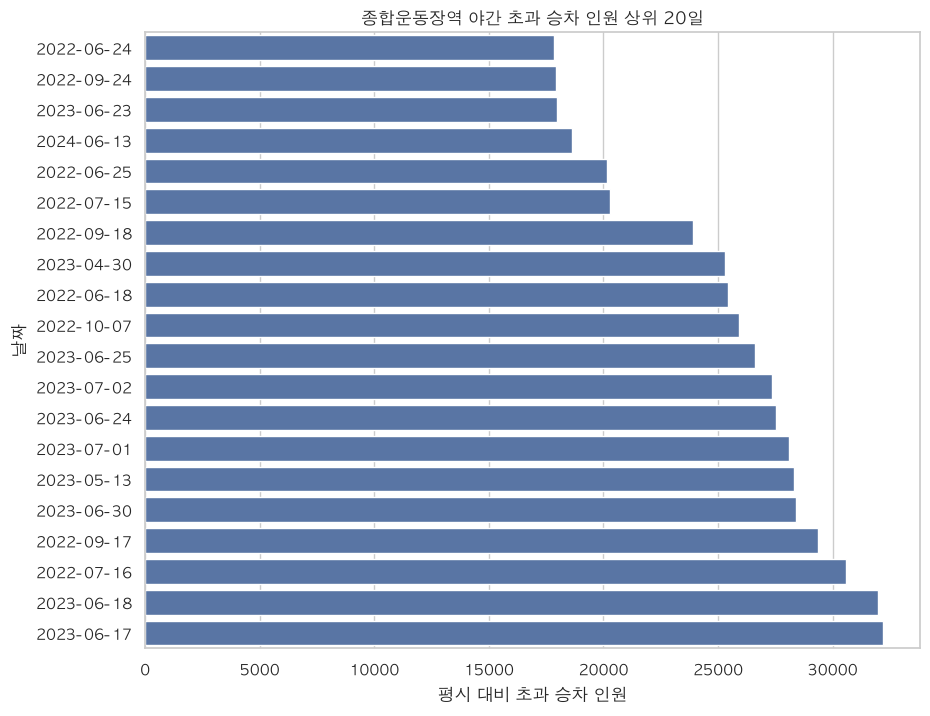

In [61]:
top20_stadium_days = (
    stadium_eda_result
    .sort_values('초과승차인원', ascending=False)
    .head(20)
    .sort_values('초과승차인원')
)
plt.figure(figsize=(10, 8))

sns.barplot(
    data=top20_stadium_days,
    x='초과승차인원',
    y='수송일자'
)

plt.title('종합운동장역 야간 초과 승차 인원 상위 20일')
plt.xlabel('평시 대비 초과 승차 인원')
plt.ylabel('날짜')
plt.ticklabel_format(style='plain', axis='x')
plt.show()

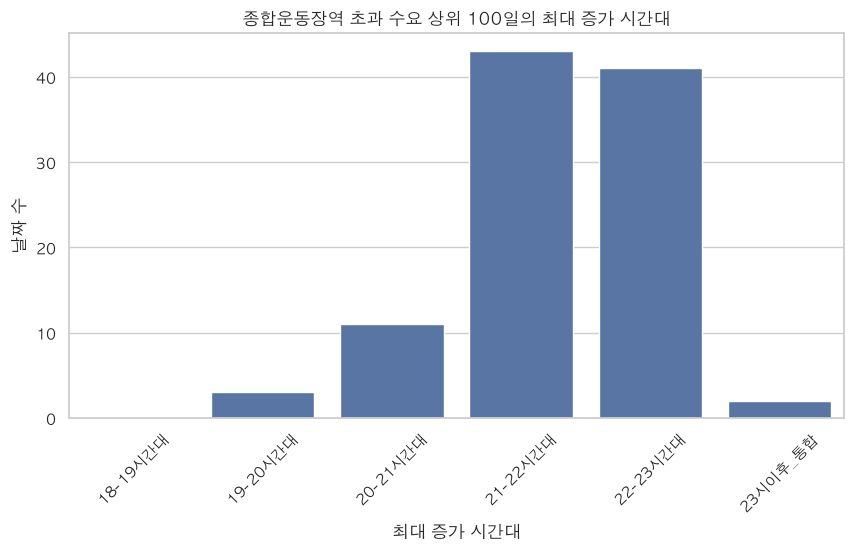

In [62]:
# 최대 증가 시간대 분포 확인

top100_stadium_days = (
    stadium_eda_result
    .sort_values('초과승차인원', ascending=False)
    .head(100)
)

peak_hour_count = (
    top100_stadium_days['최대증가시간대']
    .value_counts()
    .reindex(evening_cols, fill_value=0)
    .reset_index()
)

peak_hour_count.columns = ['최대증가시간대', '날짜수']

peak_hour_count

plt.figure(figsize=(10, 5))

sns.barplot(
    data=peak_hour_count,
    x='최대증가시간대',
    y='날짜수'
)

plt.title('종합운동장역 초과 수요 상위 100일의 최대 증가 시간대')
plt.xlabel('최대 증가 시간대')
plt.ylabel('날짜 수')
plt.xticks(rotation=45)
plt.show()

In [63]:
stadium_eda_result

,수송일자,연도,요일구분,실제승차인원,평시승차인원,초과승차인원,전체증가율,전체증가율_pct,최대증가시간대,최대시간대승차인원,최대시간대평시인원,최대시간대증가인원,최대시간대증가율_pct
0,2020-01-01,2020,일요일,1838.0,698.5,1148.5,1.631353,163.135290,19-20시간대,813.0,148.0,665.0,449.324324
1,2020-01-02,2020,평일,2279.0,1624.0,655.0,0.403325,40.332512,22-23시간대,470.0,147.0,323.0,219.727891
2,2020-01-03,2020,평일,3215.0,1624.0,1591.0,0.979680,97.967980,21-22시간대,671.0,215.0,456.0,212.093023
3,2020-01-04,2020,토요일,1694.0,908.5,785.5,0.864612,86.461200,21-22시간대,636.0,136.0,500.0,367.647059
4,2020-01-05,2020,일요일,2269.0,698.5,1570.5,2.248389,224.838941,18-19시간대,956.0,201.5,754.5,374.441687
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2187,2025-12-27,2025,토요일,6930.0,3596.0,3645.0,0.927141,92.714127,21-22시간대,3237.0,1092.0,2145.0,196.428571
2188,2025-12-28,2025,일요일,3551.0,1379.0,2313.5,1.575054,157.505439,20-21시간대,2316.0,303.0,2013.0,664.356436
2189,2025-12-29,2025,평일,1608.0,2681.5,0.0,-0.400336,-40.033563,23시이후_통합,77.0,108.0,-31.0,-28.703704
2190,2025-12-30,2025,평일,1588.0,2681.5,5.0,-0.407794,-40.779415,23시이후_통합,113.0,108.0,5.0,4.629630
